# VoiceVision AI

## Notebook 02 : Data Preprocessing

### Objective

This notebook prepares the waste image dataset for training EfficientNetB3.

Tasks:
- Load dataset
- Resize images
- Split into training and validation sets
- Normalize pixel values
- Apply data augmentation
- Prepare TensorFlow datasets

In [1]:
import tensorflow as tf
import os

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset"

In [4]:
IMAGE_SIZE = (300, 300)
BATCH_SIZE = 32
SEED = 42

In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.
Using 9808 files for training.


In [6]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.
Using 2451 files for validation.


In [7]:
class_names = train_dataset.class_names

print(class_names)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


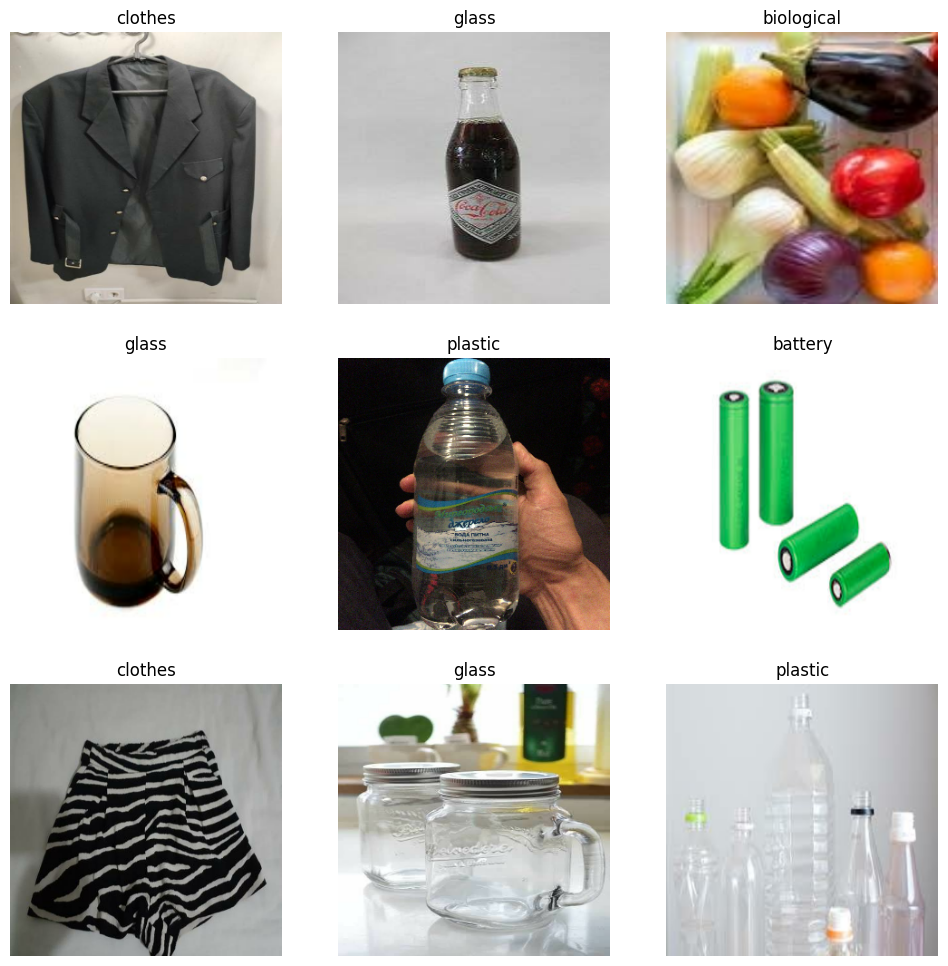

In [8]:
plt.figure(figsize=(12,12))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [11]:
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [13]:
for images, labels in train_dataset.take(1):

    print("Images Shape :", images.shape)

    print("Labels Shape :", labels.shape)

Images Shape : (32, 300, 300, 3)
Labels Shape : (32,)


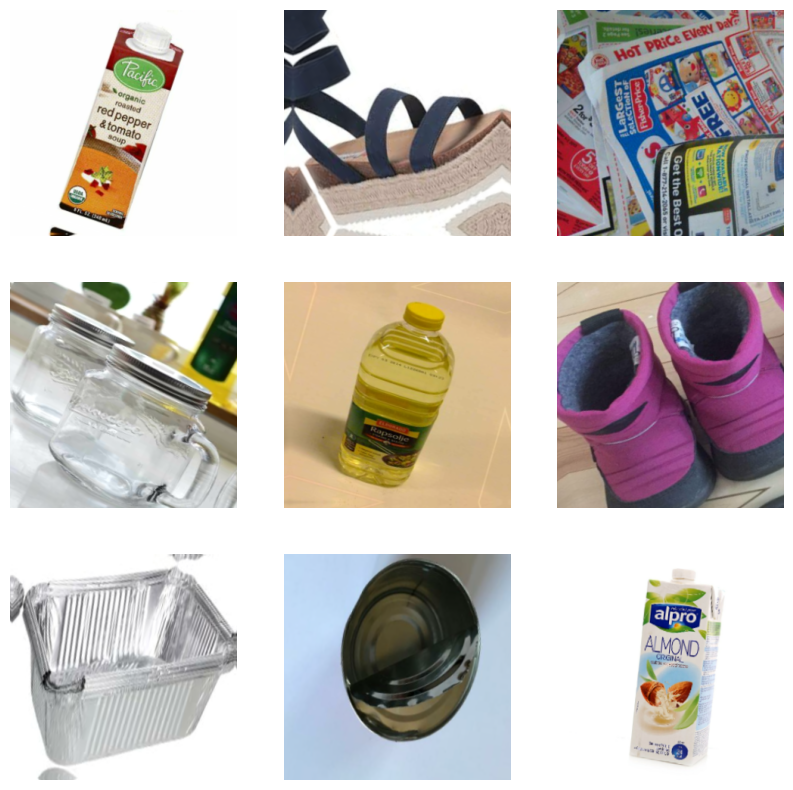

In [14]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy())

        plt.axis("off")

plt.show()

In [16]:
import os
import json

save_dir = "/content/drive/MyDrive/VoiceVision-AI/03_Trained_Models"

os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "class_names.json")

with open(save_path, "w") as f:
    json.dump(class_names, f)

print("Class names saved successfully!")

Class names saved successfully!
